In [6]:
import numpy as np
# np.random.seed(129803)

import matplotlib.pyplot as plt
plt.style.use('https://raw.githubusercontent.com/lsimek/matplotlibrc/main/lavender-dark-thin.mplstyle')

import seaborn as sns

import scipy.stats as stats
import scipy.linalg as linalg
from scipy.spatial import ConvexHull

import os
import sys

In [2]:
def chull_plot(ax, vertices, hull, colorid='2', lw=1.5, style='--', **kwargs):
    hv = hull.vertices
    hv = np.hstack((hv, hv[0]))
    
    ax.plot(vertices[hv,0], vertices[hv,1], linestyle=style, lw=lw, color=f'C{colorid}', **kwargs)

def get_walk(n=100, drift_vec=np.array([0,0]), sigma=1):
    w  = np.random.normal(size=(n-1,2))
    w = np.vstack((np.array([0,0]),w))

    drift = np.tile(drift_vec,n).reshape(n,2)

    return w.cumsum(axis=0) + ( drift.cumsum(axis=0) - drift_vec )

def plot_walk(ax, w, **kwargs):
    ax.plot(w[:, 0], w[:, 1], **kwargs)

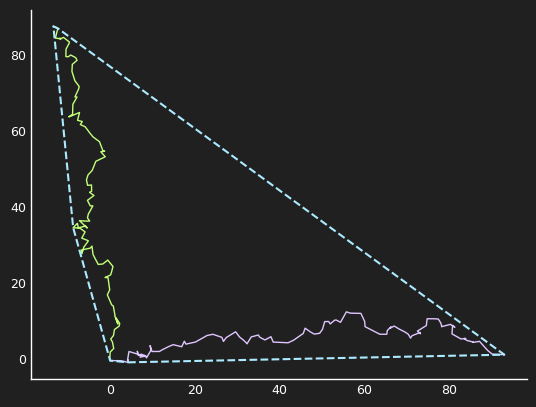

In [7]:
fig, ax = plt.subplots()

n = 100
w1 = get_walk(n, np.array([1,0]), sigma=2)
w2 = get_walk(n, np.array([0,1]), sigma=3)

ax.plot(w1[:,0],w1[:,1])
ax.plot(w2[:,0],w2[:,1])

allw = np.vstack((w1,w2))
hull = ConvexHull(allw)
chull_plot(ax, allw, hull)

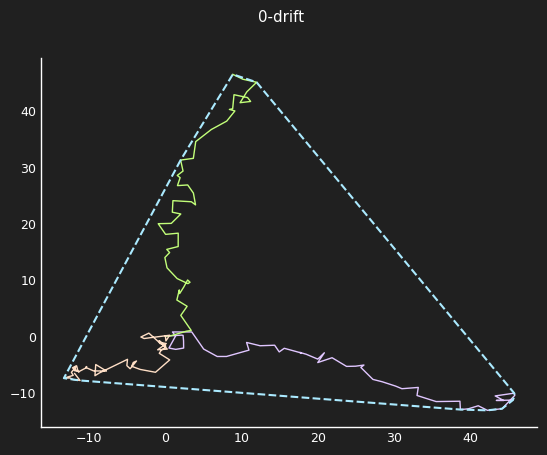

In [45]:
fig, ax = plt.subplots()
fig.suptitle('0-drift')

n = 50
w1 = get_walk(n, np.array([1,0]), sigma=2)
w2 = get_walk(n, np.array([0,1]), sigma=3)
w3 = get_walk(n, np.array([0,0]), sigma=2.5)


ax.plot(w1[:,0],w1[:,1])
ax.plot(w2[:,0],w2[:,1])
plot_walk(ax,w3,color='C6')

allw = np.vstack((w1,w2,w3))
hull = ConvexHull(allw)
chull_plot(ax, allw, hull)

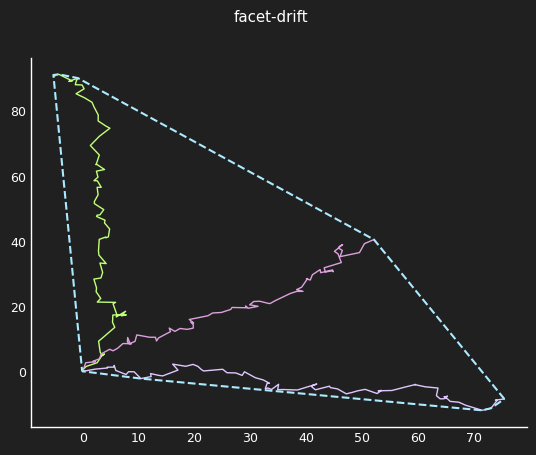

In [128]:
fig, ax = plt.subplots()
fig.suptitle('facet-drift')

n = 75
w1 = get_walk(n, np.array([1,0]), sigma=2)
w2 = get_walk(n, np.array([0,1]), sigma=3)
w3 = get_walk(n, np.array([1/2,1/2]) , sigma=2.5)


ax.plot(w1[:,0],w1[:,1])
ax.plot(w2[:,0],w2[:,1])
plot_walk(ax,w3,color='C5')

allw = np.vstack((w1,w2,w3))
hull = ConvexHull(allw)
chull_plot(ax, allw, hull)

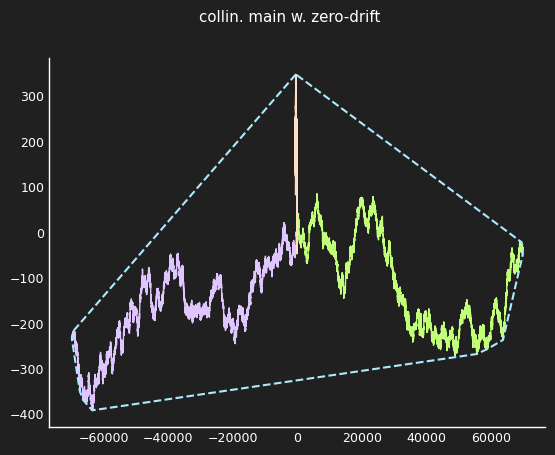

In [270]:
fig, ax = plt.subplots()
fig.suptitle('collin. main w. zero-drift')

n = 70000
w1 = get_walk(n, np.array([-1,0]), sigma=2)
w2 = get_walk(n, np.array([1,0]), sigma=3)
# w3 = get_walk(n, np.array([1/2,1/2]) , sigma=2.5)
w4 = get_walk(n, np.array([0,0]) , sigma=1.5)

ax.plot(w1[:,0],w1[:,1])
ax.plot(w2[:,0],w2[:,1])
# plot_walk(ax,w3,color='C5')
plot_walk(ax,w4,color='C6')

allw = np.vstack((w1,w2,w4))  # pazi
hull = ConvexHull(allw)
chull_plot(ax, allw, hull)

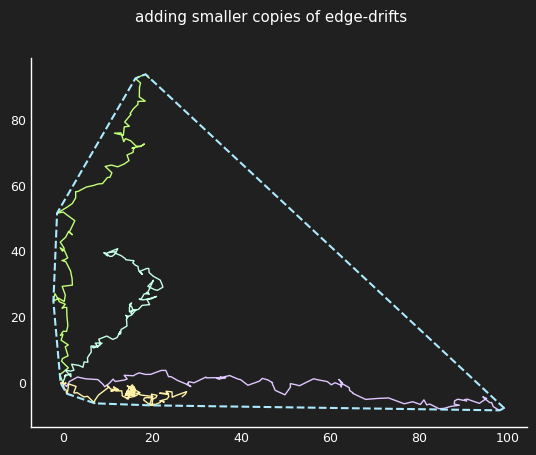

In [269]:
fig, ax = plt.subplots()
fig.suptitle('adding smaller copies of edge-drifts')

n = 100
w1 = get_walk(n, np.array([1,0]), sigma=2)
w2 = get_walk(n, np.array([0,1]), sigma=2)

w3 = get_walk(n, np.array([1/4,0]), sigma=2)
w4 = get_walk(n, np.array([0,1/4]), sigma=2)

plot_walk(ax,w1,color='C0')
plot_walk(ax,w2,color='C1')
plot_walk(ax,w3,color='C3')
plot_walk(ax,w4,color='C4')

allw = np.vstack((w1,w2,w3,w4))
hull = ConvexHull(allw)
chull_plot(ax, allw, hull, colorid=2)